# Инородные предметы у позвоночника: сегментация + копи-пейст

Критерий: «наличие посторонних предметов» на снимке позвоночника. Разметка (CVAT): `wire` — дужки лифчика (ломаные), `посторонний_предмет` — застёжки и прочий металл (боксы).
Позитивов всего 20 из 99, поэтому:

- **Копи-пейст аугментация.** Из размеченных снимков **обучающей части** вырезаются дужки и предметы (только «светлая добавка» над фоном), случайно поворачиваются, масштабируются
  и вставляются на чистые снимки с точной маской. Донорами служат только обучающие фолды — валидационный и тестовый снимок в аугментацию не попадают.
- **Сегментация, а не бокс:** дужка — тонкая изогнутая линия, бокс на ней почти весь пустой. Модель предсказывает 2 канала масок (дужка, предмет); решение «на снимке есть предмет» = число пикселей маски выше порога.
- **Одна модель на всех данных** (без кросс-валидации: позитивов 20, несколько обучений не нужны), фиксированное число эпох. В конце показано, как модель сработала на обучающих снимках (оптимистично) и на внешних, если они есть.
- **Предмет на снимке один** (застёжка), поэтому из зелёных областей остаётся одна, самая уверенная.
- **Мелочь в предсказании убирается:** зелёные компоненты (после слияния близких кусков в одну область) меньше `MIN_OBJ_COMP_PX`, красные короче `MIN_WIRE_LEN_PX` не рисуются и не входят в счёт.
- Что печатается в конце: сколько размеченных позитивов найдено, сколько чистых снимков дало ложное срабатывание, кто именно ошибся, картинки.

In [49]:
!pip install -q timm scikit-learn

In [50]:
import os, json, random, math
import numpy as np
import pandas as pd
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import timm
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

SEED = 42
def set_full_determinism(seed=SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True; torch.backends.cudnn.benchmark = False
set_full_determinism()

def worker_init_fn(worker_id):
    s = torch.initial_seed() % (2 ** 32); random.seed(s); np.random.seed(s)

## Конфигурация

In [51]:
PACKAGE_DIR = "/kaggle/input/datasets/cgvhbjmk/dxa-data/training_package"  # images/, foreign_labels.json (положите рядом с manifest.csv)
IMAGES_DIR = os.path.join(PACKAGE_DIR, "images")
LABELS_PATH = os.path.join(PACKAGE_DIR, "foreign_labels.json")
OUTPUT_DIR = "./outputs_foreign"
os.makedirs(OUTPUT_DIR, exist_ok=True)

TOP_FRAC = 0.4                 # модели подаётся только верхняя часть кадра: все дужки лежат выше 0.32 высоты, предметы (кроме одного) выше 0.31
IMG_W, IMG_H = 320, 128        # верхние 40% снимка (~300x120) приводятся к 320x128 (кратно 32); дужка ~5 px толщиной остаётся видна
WIRE_WIDTH_PX = 5              # толщина маски дужки (в пикселях исходного снимка)
BACKBONE = "resnet18.tv_in1k"
N_FOLDS = 5
EPOCHS, PATIENCE, BATCH_SIZE, LR, WEIGHT_DECAY = 60, 12, 8, 3e-4, 1e-4
STEPS_MULT = 3                 # за эпоху обучающие снимки проходят несколько раз (разные вставки)

# копи-пейст
PASTE_PROB = 0.7               # вероятность вставки на чистый снимок
PASTE_ON_POSITIVE_PROB = 0.3   # вероятность дополнительной вставки на реальный позитив
# Дужки лифчика — не случайные штрихи: они стоят там же, где на исходном снимке (положение берётся от донора, с небольшим сдвигом), наклон сохраняется
# (у левой и правой сторон он зеркальный). Режимы: none — без дужек; single — одна; pair — пара, симметричная относительно оси кадра (зеркальная копия);
# parallel — две параллельные (тот же изгиб, сдвиг вниз), редко с зеркальной парой (3-4 дужки).
WIRE_MODES = ["none", "single", "pair", "parallel"]; WIRE_MODES_P = [0.15, 0.30, 0.40, 0.15]
PARALLEL_MIRROR_PROB = 0.3
PARALLEL_DY_FRAC = (0.06, 0.14)  # сдвиг второй параллельной дужки, доля высоты кадра
WIRE_JITTER = (0.03, 0.03)       # сдвиг положения дужки от донорского (доля ширины, высоты)
WIRE_ROT_DEG, WIRE_SCALE = 3, (0.92, 1.08)
WIRE_MAX_TILT_DEG = 30           # доноры-дужки только с наклоном хорды не круче этого
PASTE_N_OBJ = [0, 1];         PASTE_N_OBJ_P = [0.5, 0.5]   # застёжка на снимке одна
OBJ_JITTER = (0.06, 0.06)
OBJ_ROT_DEG, OBJ_SCALE = 15, (0.8, 1.25)
PASTE_GAIN = (0.8, 1.2)        # яркость вставки
BG_MEDIAN_PX = 25              # размер медианного фона, вычитаемого при вырезании (остаётся только «светлая добавка»)
WIRE_BAND_PX = 9               # полоса вокруг дужки при вырезании
MASK_THRESH = 0.5
# Цель для предметов — не весь бокс, а яркие пиксели внутри него (светлая добавка над медианным фоном > порога), слитые в ОДНУ сплошную область (выпуклая оболочка): бокс просторный, а предмет мелкий и острый.
OBJ_BRIGHT_THRESH = 30
OBJ_DILATE_PX = 3
OBJ_MIN_MX = 77                # зелёная область отсеивается, если максимум яркости над медианным фоном внутри неё меньше (по OOF: 19/19 позитивов при 9/80 ложных; ребра и мягкие образования слабее)
MAX_OBJECTS = 1                # застёжка на снимке одна: из всех зелёных областей остаётся самая уверенная (в коде — одна)
OBJ_MERGE_PX = 9               # куски одного предмета (и в разметке, и в предсказании) сливаются в одну область: замыкание этим ядром + выпуклая оболочка
# Мелочь в предсказании убирается (и в счёте, и на картинках), размеры в пикселях кадра 320x128:
MIN_OBJ_COMP_PX = 60           # зелёные компоненты площадью меньше — не рисуем и не считаем (у разметки после порога яркости 110-1300 px)
MIN_WIRE_ASPECT = 2.5          # красная компонента остаётся, только если длинная сторона минимального прямоугольника не меньше этого числа коротких (дужка — линия, а не пятно)
MAX_WIRE_TOP_FRAC = 0.15       # красная компонента остаётся, только если её верхний край не ниже этой доли высоты кадра (по OOF: у 23 из 24 настоящих красных верх у самого верха, у трёх ложных 0.20-0.55)
MIN_WIRE_LEN_PX = 30           # красные компоненты, у которых диагональ ограничивающего прямоугольника короче, — не рисуем и не считаем (у разметки в основном 39-119)
MIN_WIRE_VERDICT_PX = 1        # красных пикселей после очистки (мелочь уже убрана) для вердикта «ПРЕДМЕТ»
MIN_AREA_PX = 30               # снимок с предметом, если пикселей маски (p>0.5, в 320x128) не меньше этого; уточняется по OOF
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


## Данные и маски

Маски строятся по разметке: канал 0 — дужки (ломаная толщиной `WIRE_WIDTH_PX`), канал 1 — предметы: **яркие пиксели внутри бокса** (над медианным фоном), а не весь бокс — предмет мелкий и острый, бокс просторный.

In [52]:
labels = json.load(open(LABELS_PATH, encoding="utf-8"))
names = sorted(labels)
df = pd.DataFrame({"image_filename": names})

def read_gray(name):
    return cv2.imread(os.path.join(IMAGES_DIR, name), cv2.IMREAD_GRAYSCALE)

def residual(img_u8):
    bg = cv2.medianBlur(img_u8, BG_MEDIAN_PX)
    return np.clip(img_u8.astype(np.float32) - bg.astype(np.float32), 0, 255)

def label_masks(name, img):
    h, w = img.shape
    m = np.zeros((2, h, w), np.uint8)
    for pts in labels[name]["wires"]:
        cv2.polylines(m[0], [np.round(np.array(pts)).astype(np.int32)], False, 1, WIRE_WIDTH_PX)
    res = residual(img)
    for x0, y0, x1, y1 in labels[name]["boxes"]:
        box = np.zeros((h, w), np.uint8); box[max(int(round(y0)), 0):int(round(y1)), max(int(round(x0)), 0):int(round(x1))] = 1
        bright = cv2.dilate(((res > OBJ_BRIGHT_THRESH) & (box > 0)).astype(np.uint8), np.ones((OBJ_DILATE_PX, OBJ_DILATE_PX), np.uint8)) & box
        if bright.sum() >= 10:
            hull = np.zeros((h, w), np.uint8)
            cv2.fillConvexPoly(hull, cv2.convexHull(cv2.findNonZero(bright)), 1)   # один предмет = одна область, а не россыпь пятен
            m[1] |= hull & box
        else:
            m[1] |= box   # если ярких пикселей нет вовсе — весь бокс
    return m

FULL = {n: read_gray(n) for n in names}
IMAGES, MASKS = {}, {}
for n in names:
    hcut = int(round(FULL[n].shape[0] * TOP_FRAC))            # верхняя часть; разметка вне её отбрасывается
    IMAGES[n] = FULL[n][:hcut]
    MASKS[n] = label_masks(n, FULL[n])[:, :hcut]
df["has_obj"] = [int(MASKS[n].any()) for n in names]         # позитив = после обрезки в кадре что-то осталось
lost = [n[:8] for n in names if (labels[n]["wires"] or labels[n]["boxes"]) and not MASKS[n].any()]
if lost:
    print("разметка целиком вне верхней части кадра (снимок считается чистым):", lost)
skf = StratifiedKFold(N_FOLDS, shuffle=True, random_state=SEED)
df["fold"] = -1
for k, (_, te) in enumerate(skf.split(df, df.has_obj)):
    df.loc[te, "fold"] = k
print(df.groupby("fold").has_obj.agg(["size", "sum"]).rename(columns={"size": "снимков", "sum": "с предметом"}))

разметка целиком вне верхней части кадра (снимок считается чистым): ['34b31f92']
      снимков  с предметом
fold                      
0          20            4
1          20            4
2          20            4
3          20            4
4          19            3


## Банк вставок (копи-пейст)

Из размеченного снимка берётся полоса вокруг дужки / бокс предмета; из неё вычитается медианный фон, остаётся светлая добавка (`residual`). Вставка = добавить эту добавку на новое место (с поворотом/масштабом/зеркалом), маска поворачивается вместе с ней.

In [53]:
def residual(img_u8):
    bg = cv2.medianBlur(img_u8, BG_MEDIAN_PX)
    return np.clip(img_u8.astype(np.float32) - bg.astype(np.float32), 0, 255)

def feather(m, sigma=1.5):
    return np.clip(cv2.GaussianBlur(m.astype(np.float32), (0, 0), sigma), 0, 1)

def crop_box(m, margin=4):
    ys, xs = np.where(m > 0)
    return max(xs.min() - margin, 0), max(ys.min() - margin, 0), xs.max() + margin + 1, ys.max() + margin + 1

def build_bank(train_names):
    # patches: kind, res (float32 hxw, уже умножена на растушёванную полосу), tgt (hxw uint8 маска цели), cxf/cyf — центр донора в долях кадра
    bank = []
    for n in train_names:
        img = IMAGES[n]; res = residual(img); H, W = img.shape
        for pts in labels[n]["wires"]:
            thin = np.zeros(img.shape, np.uint8)
            cv2.polylines(thin, [np.round(np.array(pts)).astype(np.int32)], False, 1, WIRE_WIDTH_PX)
            if thin.sum() < 20:
                continue   # дужка почти целиком вне верхней части
            q = np.array(pts); tilt = np.degrees(np.arctan2(q[-1, 1] - q[0, 1], q[-1, 0] - q[0, 0]))
            tilt = (tilt + 90) % 180 - 90                      # наклон хорды без учёта направления рисования, градусы
            if abs(tilt) > WIRE_MAX_TILT_DEG:
                continue   # крутые куски дужек как доноры не берём: настоящая дужка идёт полого
            band = cv2.dilate(thin, np.ones((WIRE_BAND_PX, WIRE_BAND_PX), np.uint8))
            x0, y0, x1, y1 = crop_box(band)
            bank.append({"kind": "wire", "res": (res * feather(band))[y0:y1, x0:x1], "tgt": thin[y0:y1, x0:x1], "src": n,
                         "cxf": (x0 + x1) / 2 / W, "cyf": (y0 + y1) / 2 / H})
        for bx0, by0, bx1, by1 in labels[n]["boxes"]:
            box = np.zeros(img.shape, np.uint8); box[max(int(by0), 0):int(by1), max(int(bx0), 0):int(bx1)] = 1
            obj = MASKS[n][1] & box                              # яркие пиксели предмета внутри бокса
            if obj.sum() < 10:
                continue
            band = cv2.dilate(obj, np.ones((5, 5), np.uint8))
            X0, Y0, X1, Y1 = crop_box(band, 2)
            bank.append({"kind": "obj", "res": (res * feather(band, 1.0))[Y0:Y1, X0:X1], "tgt": obj[Y0:Y1, X0:X1], "src": n,
                         "cxf": (X0 + X1) / 2 / W, "cyf": (Y0 + Y1) / 2 / H})
    return bank

def place(patch, canvas_hw, cx, cy, flip, ang, sc):
    # переносит вставку на холст: центр (cx, cy) в пикселях, зеркало, поворот, масштаб; возвращает добавку и маску цели на холсте
    H, W = canvas_hw; ph, pw = patch["res"].shape
    M = cv2.getRotationMatrix2D((pw / 2, ph / 2), ang, sc)
    M[:, 2] += (cx - pw / 2, cy - ph / 2)
    res = patch["res"][:, ::-1] if flip else patch["res"]
    tgt = patch["tgt"][:, ::-1] if flip else patch["tgt"]
    add_ = cv2.warpAffine(np.ascontiguousarray(res), M, (W, H), flags=cv2.INTER_LINEAR, borderValue=0)
    t = cv2.warpAffine(np.ascontiguousarray(tgt).astype(np.float32), M, (W, H), flags=cv2.INTER_LINEAR, borderValue=0) > 0.3
    return add_, t

def paste_random(img_u8, mask2, bank, rng):
    H, W = img_u8.shape
    wires = [p for p in bank if p["kind"] == "wire"]; objs = [p for p in bank if p["kind"] == "obj"]
    mode = str(rng.choice(WIRE_MODES, p=WIRE_MODES_P)) if wires else "none"
    n_obj = int(rng.choice(PASTE_N_OBJ, p=PASTE_N_OBJ_P)) if objs else 0
    if mode == "none" and n_obj == 0:
        mode, n_obj = ("single", 0) if wires else ("none", 1)
    out = img_u8.astype(np.float32); m = mask2.copy()

    def put(p, cxf, cyf, flip, ang, sc, gain, dy=0.0):
        nonlocal out
        cx = (1 - cxf if flip else cxf) * W            # зеркало кадра: положение отражается вместе с дужкой
        add_, t = place(p, (H, W), cx, (cyf + dy) * H, flip, -ang if flip else ang, sc)
        out = out + add_ * gain; m[0 if p["kind"] == "wire" else 1] |= t.astype(np.uint8)

    if mode != "none":
        p = wires[rng.integers(len(wires))]; gain = rng.uniform(*PASTE_GAIN); sc = rng.uniform(*WIRE_SCALE); ang = rng.uniform(-WIRE_ROT_DEG, WIRE_ROT_DEG)
        cxf = float(np.clip(p["cxf"] + rng.normal(0, WIRE_JITTER[0]), 0.05, 0.95)); cyf = float(np.clip(p["cyf"] + rng.normal(0, WIRE_JITTER[1]), 0.05, 0.9))
        flip = bool(rng.random() < 0.5)
        put(p, cxf, cyf, flip, ang, sc, gain)
        if mode == "pair":
            put(p, cxf, cyf + rng.normal(0, 0.02), not flip, ang, sc, gain)                    # симметричная пара по обе стороны от позвоночника
        elif mode == "parallel":
            dy = rng.uniform(*PARALLEL_DY_FRAC)
            put(p, cxf, cyf, flip, ang, sc, gain, dy=dy)                                         # та же дужка ниже, тот же изгиб и наклон
            if rng.random() < PARALLEL_MIRROR_PROB:
                put(p, cxf, cyf, not flip, ang, sc, gain); put(p, cxf, cyf, not flip, ang, sc, gain, dy=dy)
    for _ in range(n_obj):
        p = objs[rng.integers(len(objs))]
        cxf = float(np.clip(p["cxf"] + rng.normal(0, OBJ_JITTER[0]), 0.03, 0.97)); cyf = float(np.clip(p["cyf"] + rng.normal(0, OBJ_JITTER[1]), 0.05, 0.95))
        put(p, cxf, cyf, bool(rng.random() < 0.5), rng.uniform(-OBJ_ROT_DEG, OBJ_ROT_DEG), rng.uniform(*OBJ_SCALE), rng.uniform(*PASTE_GAIN))
    return np.clip(out, 0, 255).astype(np.uint8), m

## Датасет и аугментации

In [54]:
def affine_aug(img, m, rng):
    h, w = img.shape
    if rng.random() < 0.5:
        img = img[:, ::-1]; m = m[:, :, ::-1]
    ang, sc = rng.uniform(-5, 5), rng.uniform(0.92, 1.08)
    M = cv2.getRotationMatrix2D((w / 2, h / 2), ang, sc); M[:, 2] += (rng.uniform(-0.04, 0.04) * w, rng.uniform(-0.04, 0.04) * h)
    img = cv2.warpAffine(np.ascontiguousarray(img), M, (w, h), flags=cv2.INTER_LINEAR, borderValue=0)
    m = np.stack([cv2.warpAffine(np.ascontiguousarray(mm), M, (w, h), flags=cv2.INTER_NEAREST, borderValue=0) for mm in m])
    g = rng.uniform(0.8, 1.25)
    img = np.clip(255.0 * (img.astype(np.float32) / 255.0) ** g, 0, 255).astype(np.uint8)
    return img, m

class ForeignDataset(Dataset):
    def __init__(self, names_, bank=None, train=False, steps_mult=1):
        self.names = list(names_) * (steps_mult if train else 1); self.bank = bank; self.train = train

    def __len__(self):
        return len(self.names)

    def __getitem__(self, i):
        n = self.names[i]; img = IMAGES[n]; m = MASKS[n]
        if self.train:
            rng = np.random.default_rng(np.random.randint(0, 2 ** 31 - 1))  # np.random засеян worker_init_fn
            pos = bool(m.any())
            if self.bank and rng.random() < (PASTE_ON_POSITIVE_PROB if pos else PASTE_PROB):
                img, m = paste_random(img, m, self.bank, rng)
            img, m = affine_aug(img, m, rng)
        x = cv2.resize(img, (IMG_W, IMG_H), interpolation=cv2.INTER_LINEAR)
        y = np.stack([cv2.resize(np.ascontiguousarray(mm).astype(np.uint8), (IMG_W, IMG_H), interpolation=cv2.INTER_NEAREST) for mm in m])
        x = (x.astype(np.float32) / 255.0 - 0.449) / 0.226
        return torch.from_numpy(x)[None].repeat(3, 1, 1), torch.from_numpy(y.astype(np.float32))

### Как выглядят вставки (проверка)

Сверху — чистый снимок, снизу — он же со вставками; красный — маска дужек, зелёный — маска предметов.

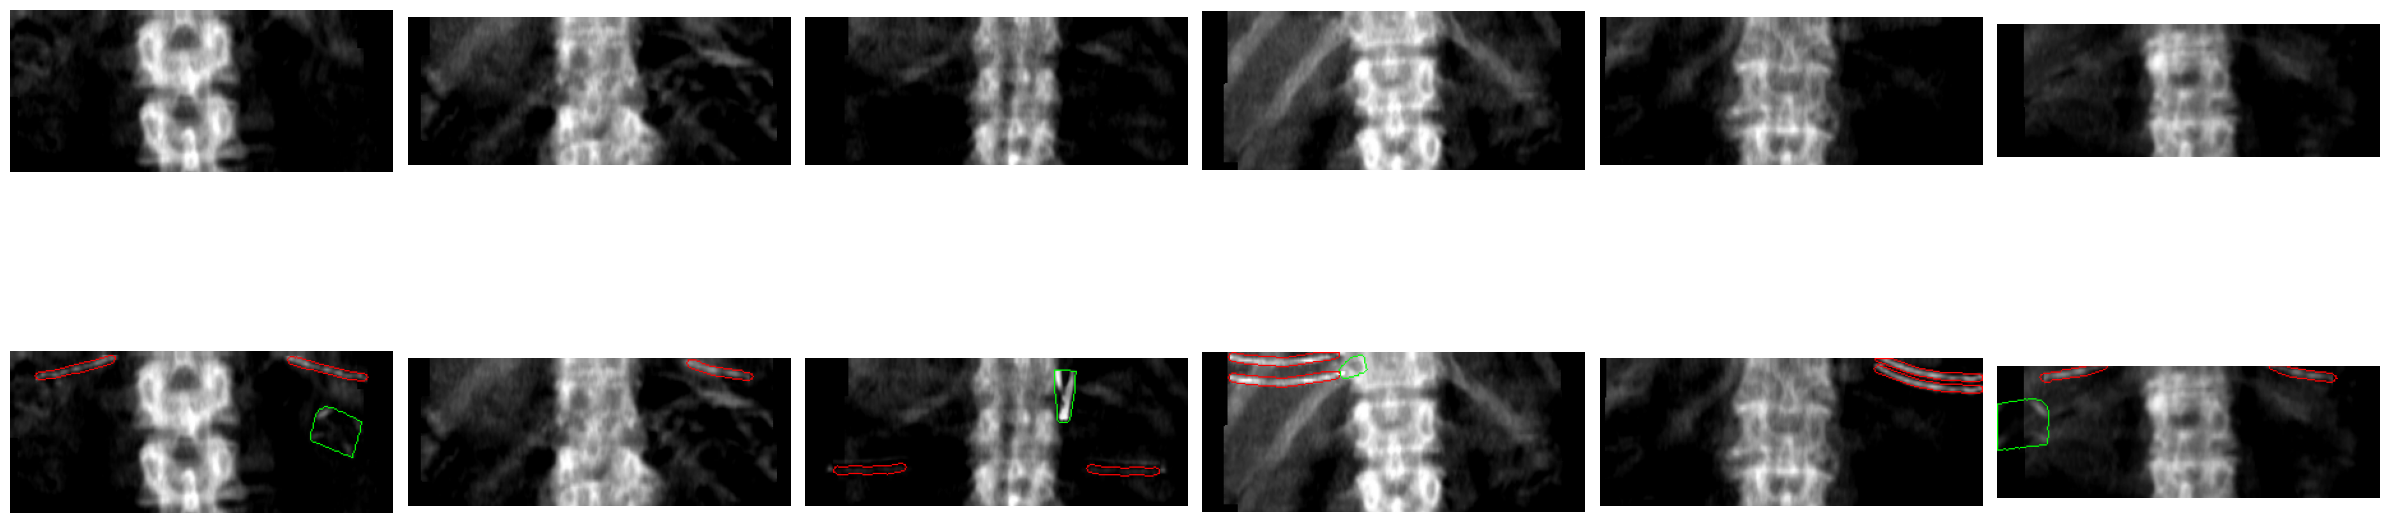

вставок в банке: дужек 22, предметов 7


In [55]:
def overlay(img, m):
    # только контуры масок, чтобы не закрывать сам предмет
    a = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    for c, col in ((0, (255, 0, 0)), (1, (0, 255, 0))):
        cnt, _ = cv2.findContours((m[c] > 0).astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(a, cnt, -1, col, 1)
    return a

demo_bank = build_bank(df[(df.fold != 0) & (df.has_obj == 1)].image_filename)
clean = df[(df.fold == 0) & (df.has_obj == 0)].image_filename.tolist()[:6]
rng_demo = np.random.default_rng(1)
fig, ax = plt.subplots(2, 6, figsize=(24, 9))
for j, n in enumerate(clean):
    pi, pm = paste_random(IMAGES[n], MASKS[n], demo_bank, rng_demo)
    ax[0, j].imshow(IMAGES[n], cmap="gray"); ax[1, j].imshow(overlay(pi, pm))
    for a_ in ax[:, j]: a_.axis("off")
plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR, "paste_examples.png"), dpi=80); plt.show()
print(f"вставок в банке: дужек {sum(p['kind']=='wire' for p in demo_bank)}, предметов {sum(p['kind']=='obj' for p in demo_bank)}")

## Модель

Энкодер `timm` (ResNet-18) + декодер типа U-Net с пропусками; выход — 2 канала (дужка, предмет) в разрешении входа.

In [56]:
class ConvBlock(nn.Sequential):
    def __init__(self, cin, cout):
        super().__init__(nn.Conv2d(cin, cout, 3, padding=1, bias=False), nn.BatchNorm2d(cout), nn.ReLU(inplace=True))

class ForeignSegModel(nn.Module):
    def __init__(self, name=BACKBONE, pretrained=True):
        super().__init__()
        self.enc = timm.create_model(name, pretrained=pretrained, features_only=True, out_indices=(0, 1, 2, 3, 4))
        ch = self.enc.feature_info.channels()   # 64, 64, 128, 256, 512 (шаги 2..32)
        self.top = ConvBlock(ch[4], 128)
        self.fuse = nn.ModuleList([ConvBlock(128 + ch[i], 128) for i in range(4)])
        self.head = nn.Sequential(ConvBlock(128 + 3, 64), nn.Conv2d(64, 2, 1))

    def forward(self, x):
        feats = self.enc(x); h = self.top(feats[4])
        for i in (3, 2, 1, 0):
            h = F.interpolate(h, size=feats[i].shape[-2:], mode="bilinear", align_corners=False)
            h = self.fuse[i](torch.cat([h, feats[i]], 1))
        h = F.interpolate(h, size=x.shape[-2:], mode="bilinear", align_corners=False)
        return self.head(torch.cat([h, x], 1))   # исходный кадр подмешан на последнем шаге: тонкие линии не теряются

def seg_loss(logits, target, pos_weight=8.0):
    bce = F.binary_cross_entropy_with_logits(logits, target, pos_weight=torch.tensor(pos_weight, device=logits.device))
    p = torch.sigmoid(logits); inter = (p * target).sum((2, 3)); den = p.sum((2, 3)) + target.sum((2, 3))
    dice = 1 - (2 * inter + 1) / (den + 1)
    return bce + dice.mean()

## Обучение (одна модель) и оценка на снимок

In [57]:
def make_batch(ds, idx):
    b = [ds[k] for k in idx]
    return torch.stack([t[0] for t in b]).to(device), torch.stack([t[1] for t in b]).to(device)

@torch.no_grad()
def predict_probs(model, names_):
    model.eval(); out = {}
    ds = ForeignDataset(names_)
    for i in range(0, len(ds), BATCH_SIZE):
        idx = range(i, min(i + BATCH_SIZE, len(ds)))
        pr = torch.sigmoid(model(make_batch(ds, idx)[0])).cpu().numpy()
        for j, p in zip(idx, pr):
            out[ds.names[j]] = p
    return out

def pred_masks(prob2, top_u8=None):
    # бинарные маски (2, IMG_H, IMG_W) без мелочи: красные (дужки) короче MIN_WIRE_LEN_PX и зелёные (предметы) меньше MIN_OBJ_COMP_PX убираются
    out = np.zeros((2, prob2.shape[1], prob2.shape[2]), np.uint8)
    for c in range(2):
        bin_ = (prob2[c] > MASK_THRESH).astype(np.uint8)
        if c == 1:   # предметы: куски рядом сливаются в одну область
            bin_ = cv2.morphologyEx(bin_, cv2.MORPH_CLOSE, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (OBJ_MERGE_PX, OBJ_MERGE_PX)))
        k, lab, st, _ = cv2.connectedComponentsWithStats(bin_, connectivity=8)
        best = None   # для предметов: на снимке не больше MAX_OBJECTS областей — остаётся самая уверенная (сумма вероятности по области)
        for i in range(1, k):
            w_, h_, a_ = st[i, cv2.CC_STAT_WIDTH], st[i, cv2.CC_STAT_HEIGHT], st[i, cv2.CC_STAT_AREA]
            keep = (math.hypot(w_, h_) >= MIN_WIRE_LEN_PX and st[i, cv2.CC_STAT_TOP] <= MAX_WIRE_TOP_FRAC * prob2.shape[1]) if c == 0 else a_ >= MIN_OBJ_COMP_PX
            if keep and c == 0:   # вытянутость: длинная сторона минимального прямоугольника / короткая
                (_, _), (rw, rh), _ = cv2.minAreaRect(np.column_stack(np.where(lab == i)[::-1]).astype(np.float32))
                keep = max(rw, rh) / max(min(rw, rh), 1.0) >= MIN_WIRE_ASPECT
            if not keep:
                continue
            if c == 1:
                conf = float(prob2[1][lab == i].sum())
                if best is None or conf > best[0]:
                    best = (conf, i)
            else:
                out[c][lab == i] = 1
        if c == 1 and best is not None:   # сплошная область: выпуклая оболочка
            hull_m = np.zeros(bin_.shape, np.uint8)
            cv2.fillConvexPoly(hull_m, cv2.convexHull(np.column_stack(np.where(lab == best[1])[::-1]).astype(np.int32)), 1)
            if top_u8 is not None:   # контраст: слабую область (ребро, мягкое образование) отсеиваем целиком
                m_nat = cv2.resize(hull_m, (top_u8.shape[1], top_u8.shape[0]), interpolation=cv2.INTER_NEAREST) > 0
                res_ = np.clip(top_u8.astype(np.float32) - cv2.medianBlur(top_u8, BG_MEDIAN_PX).astype(np.float32), 0, 255)
                if m_nat.any() and res_[m_nat].max() < OBJ_MIN_MX:
                    hull_m[:] = 0
            out[c] = hull_m
    return out

def resize_mask(m2, shape_hw):
    return np.stack([cv2.resize(mm, (shape_hw[1], shape_hw[0]), interpolation=cv2.INTER_NEAREST) for mm in m2])

def verdict_levels(masks2):
    # два уровня: «ПРЕДМЕТ» — есть красная маска (дужка), надёжный признак; «проверить» — только зелёная (застёжка/предмет), она слабее: подсказка, а не приговор; иначе «чисто»
    if masks2[0].sum() >= MIN_WIRE_VERDICT_PX:
        return "ПРЕДМЕТ"
    return "проверить" if masks2[1].sum() > 0 else "чисто"

def image_score(prob2, top_u8=None):
    # число пикселей очищенной маски (оба канала объединены); top_u8 — верхняя часть исходного снимка для проверки контраста зелёной области
    return int(pred_masks(prob2, top_u8).any(0).sum())

def train_model(train_names, val_names=None, epochs=EPOCHS, seed=SEED, verbose=True):
    set_full_determinism(seed)
    bank = build_bank([n for n in train_names if labels[n]["wires"] or labels[n]["boxes"]])
    ds = ForeignDataset(train_names, bank, train=True, steps_mult=STEPS_MULT)
    dl = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, worker_init_fn=worker_init_fn, drop_last=True)
    model = ForeignSegModel().to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=LR, total_steps=epochs * len(dl))
    best, best_state, best_ep, bad = 1e9, None, epochs, 0
    for ep in range(epochs):
        model.train(); tl = 0
        for xb, yb in dl:
            xb, yb = xb.to(device), yb.to(device)
            loss = seg_loss(model(xb), yb); opt.zero_grad(); loss.backward(); opt.step(); sched.step(); tl += loss.item()
        if val_names is not None:
            vds = ForeignDataset(val_names); vl = 0
            model.eval()
            with torch.no_grad():
                for j in range(0, len(vds), BATCH_SIZE):
                    idx = range(j, min(j + BATCH_SIZE, len(vds)))
                    xb, yb = make_batch(vds, idx)
                    vl += seg_loss(model(xb), yb).item() * len(idx)
            vl /= len(vds)
            if vl < best:
                best, best_ep, bad = vl, ep + 1, 0; best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
            else:
                bad += 1
            if verbose and (ep % 5 == 0 or bad == 0):
                print(f"  эпоха {ep+1}: train {tl/len(dl):.3f} val {vl:.3f} (лучшая {best:.3f} на {best_ep})")
            if bad >= PATIENCE:
                break
        elif verbose:   # без валидации (одна модель на всех данных): прогресс — потеря обучения по эпохам
            print(f"  эпоха {ep+1}/{epochs}: train {tl/len(dl):.3f}")
    if best_state is not None:
        model.load_state_dict(best_state)
    return model, best_ep

## Обучение: одна модель на всех снимках

Без кросс-валидации: одна модель обучается на всех 99 снимках позвоночника фиксированное число эпох (`FINAL_EPOCHS`), как классификатор региона и гребни. Позитивов всего 20, поэтому честной оценки по снимку нет; ниже показано, как модель срабатывает на этих же (обучающих) снимках, это оптимистично. Вся очистка масок (мелочь, вытянутость дужек, одна застёжка на снимок) сохранена.

In [58]:
FINAL_EPOCHS = 40     # фиксированное число эпох без ранней остановки (расписание OneCycle рассчитано на это число); можно поменять
final_model, _ = train_model(df.image_filename.tolist(), None, epochs=FINAL_EPOCHS)
torch.save({"state": final_model.state_dict(), "backbone": BACKBONE, "img_size": (IMG_W, IMG_H), "top_frac": TOP_FRAC, "min_area_px": MIN_AREA_PX, "mask_thresh": MASK_THRESH},
           os.path.join(OUTPUT_DIR, "foreign_seg.pt"))
print("сохранено:", os.path.join(OUTPUT_DIR, "foreign_seg.pt"), "| эпох:", FINAL_EPOCHS)

  эпоха 1/40: train 1.846
  эпоха 2/40: train 1.769
  эпоха 3/40: train 1.652
  эпоха 4/40: train 1.551
  эпоха 5/40: train 1.471
  эпоха 6/40: train 1.428
  эпоха 7/40: train 1.384
  эпоха 8/40: train 1.320
  эпоха 9/40: train 1.272
  эпоха 10/40: train 1.213
  эпоха 11/40: train 1.164
  эпоха 12/40: train 1.118
  эпоха 13/40: train 1.070
  эпоха 14/40: train 1.022
  эпоха 15/40: train 0.979
  эпоха 16/40: train 0.948
  эпоха 17/40: train 0.926
  эпоха 18/40: train 0.888
  эпоха 19/40: train 0.855
  эпоха 20/40: train 0.849
  эпоха 21/40: train 0.828
  эпоха 22/40: train 0.803
  эпоха 23/40: train 0.790
  эпоха 24/40: train 0.784
  эпоха 25/40: train 0.754
  эпоха 26/40: train 0.747
  эпоха 27/40: train 0.729
  эпоха 28/40: train 0.742
  эпоха 29/40: train 0.705
  эпоха 30/40: train 0.704
  эпоха 31/40: train 0.700
  эпоха 32/40: train 0.682
  эпоха 33/40: train 0.688
  эпоха 34/40: train 0.674
  эпоха 35/40: train 0.677
  эпоха 36/40: train 0.674
  эпоха 37/40: train 0.686
  эпоха 38

## Как сработало на обучающих снимках

Предсказание финальной модели по всем 99 снимкам (она их видела при обучении, поэтому результат оптимистичен) с полной очисткой масок. Вердикт в два уровня: «ПРЕДМЕТ» — осталась красная маска (дужка), «проверить» — только зелёная область (застёжка/предмет), иначе «чисто».

In [59]:
probs = predict_probs(final_model, df.image_filename.tolist())
masks_ = {n: pred_masks(probs[n], IMAGES[n]) for n in df.image_filename}
df["score"] = [image_score(probs[n], IMAGES[n]) for n in df.image_filename]
df["red_px"] = [int(masks_[n][0].sum()) for n in df.image_filename]
df["green_px"] = [int(masks_[n][1].sum()) for n in df.image_filename]
df["verdict"] = [verdict_levels(masks_[n]) for n in df.image_filename]
df["pred"] = (df.score >= MIN_AREA_PX).astype(int)

own = df.has_obj == 1
tab = pd.crosstab(df.has_obj.map({1: "позитив", 0: "чистый"}), df.verdict).reindex(columns=["ПРЕДМЕТ", "проверить", "чисто"], fill_value=0)
print(tab)
print(f"позитивы: ПРЕДМЕТ {(own & (df.verdict == 'ПРЕДМЕТ')).sum()}, проверить {(own & (df.verdict == 'проверить')).sum()}, пропущено {(own & (df.verdict == 'чисто')).sum()} из {own.sum()}")
print(f"чистые: ложное ПРЕДМЕТ {(~own & (df.verdict == 'ПРЕДМЕТ')).sum()}, ложное «проверить» {(~own & (df.verdict == 'проверить')).sum()} из {(~own).sum()}")

has_w = np.array([bool(MASKS[n][0].any()) for n in df.image_filename]); has_o = np.array([bool(MASKS[n][1].any()) for n in df.image_filename])
clean_ = ~(has_w | has_o)
rows = []
for name_, col, own_ in (("красный (дужки)", "red_px", has_w), ("зелёный (предметы)", "green_px", has_o)):
    rows.append({"канал": name_, "найдено на своих позитивах": f"{(df[col][own_] > 0).sum()}/{own_.sum()}", "срабатывает на чистых": f"{(df[col][clean_] > 0).sum()}/{clean_.sum()}"})
print(pd.DataFrame(rows).to_string(index=False))
print("пропущенные позитивы:", df[own & (df.verdict == 'чисто')].image_filename.str[:8].tolist())
print("ложное ПРЕДМЕТ на чистых:", df[~own & (df.verdict == 'ПРЕДМЕТ')].image_filename.str[:8].tolist())
print("ложное «проверить» на чистых:", df[~own & (df.verdict == 'проверить')].image_filename.str[:8].tolist())
df.to_csv(os.path.join(OUTPUT_DIR, "foreign_train_check.csv"), index=False)

verdict  ПРЕДМЕТ  проверить  чисто
has_obj                           
позитив       14          5      0
чистый         1          1     78
позитивы: ПРЕДМЕТ 14, проверить 5, пропущено 0 из 19
чистые: ложное ПРЕДМЕТ 1, ложное «проверить» 1 из 80
             канал найдено на своих позитивах срабатывает на чистых
   красный (дужки)                      14/14                  1/80
зелёный (предметы)                        8/9                  1/80
пропущенные позитивы: []
ложное ПРЕДМЕТ на чистых: ['270de30d']
ложное «проверить» на чистых: ['8680958a']


### Картинки: обучающие снимки

Красный — дужки, зелёный — предметы (после очистки). Показаны все позитивы и все снимки, где вердикт не «чисто»; в заголовке вердикт и разметка (`ПОЗ` — предмет размечен, `чист`).

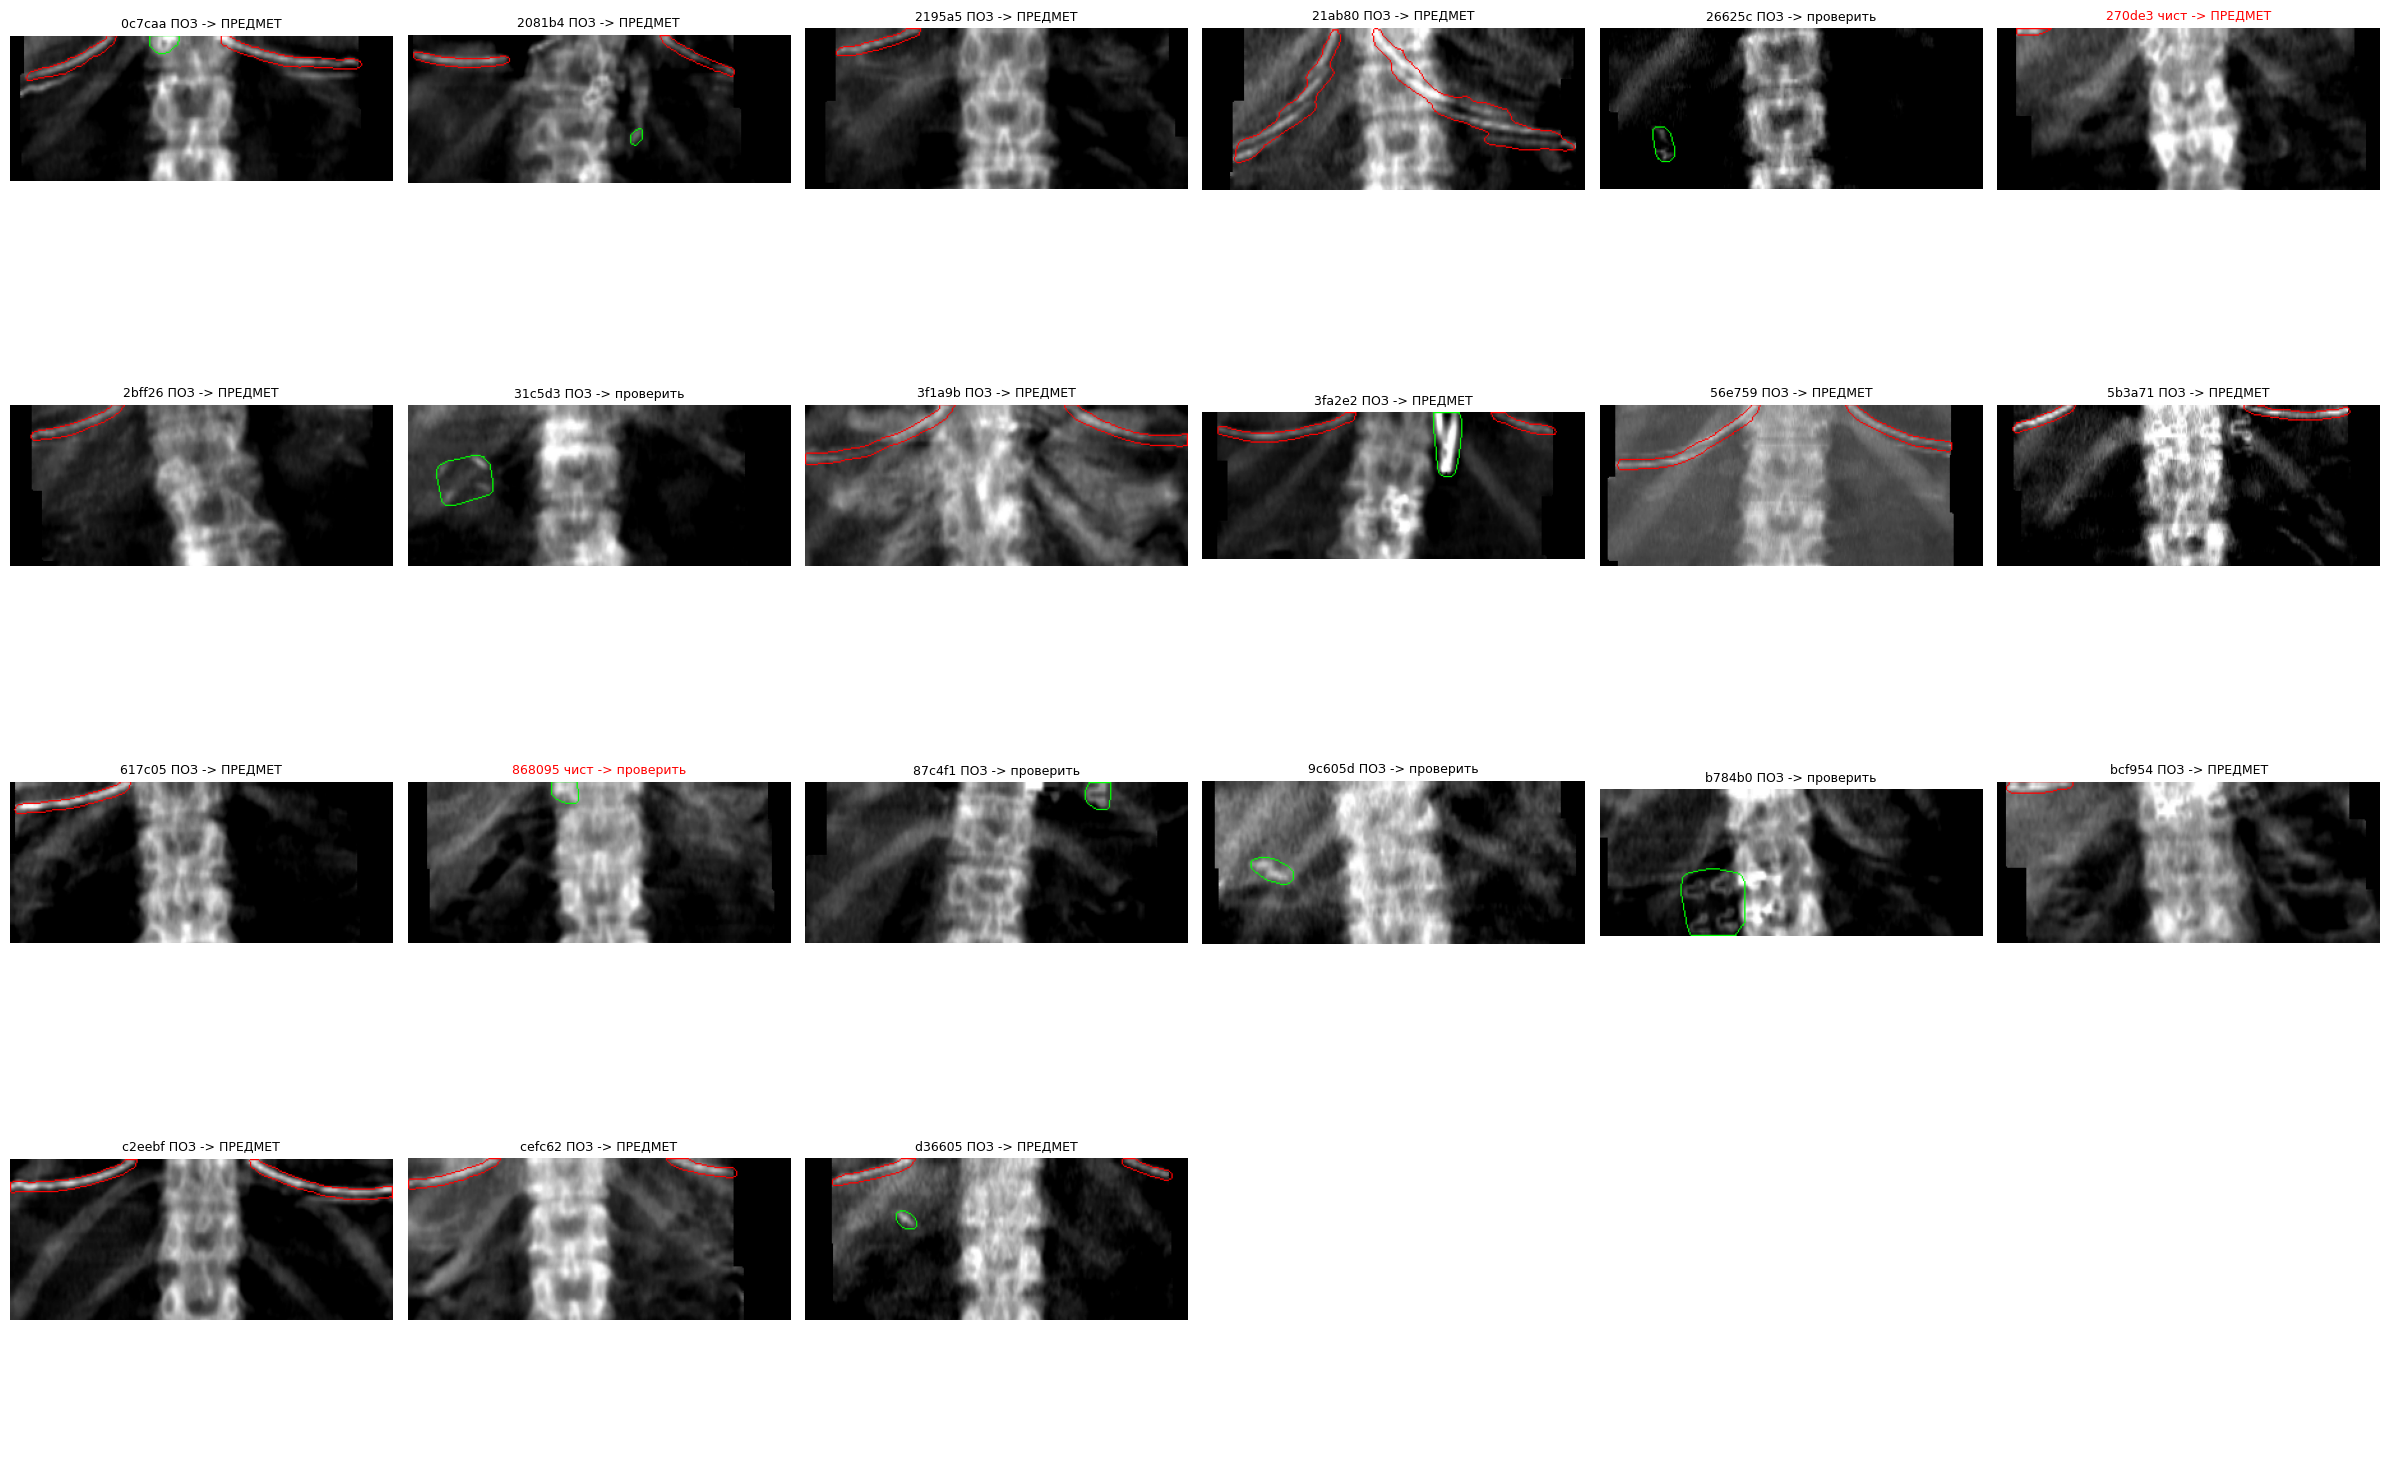

In [60]:
show = df[(df.has_obj == 1) | (df.verdict != "чисто")].reset_index(drop=True)
cols = 6; rws = math.ceil(len(show) / cols)
fig, ax = plt.subplots(rws, cols, figsize=(4 * cols, 4 * rws)); ax = np.atleast_2d(ax)
for a_ in ax.ravel(): a_.axis("off")
for i, r in show.iterrows():
    img = IMAGES[r.image_filename]
    pm = resize_mask(masks_[r.image_filename], img.shape)
    a_ = ax[i // cols, i % cols]; a_.imshow(overlay(img, pm))
    a_.set_title(f"{r.image_filename[:6]} {'ПОЗ' if r.has_obj else 'чист'} -> {r.verdict}", fontsize=9, color=("red" if (r.has_obj == 1) != (r.verdict != "чисто") else "black"))
plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR, "train_predictions.png"), dpi=70); plt.show()

## Параметры для пайплайна

Сохраняет `foreign_seg_gate.json`: параметры очистки масок и вердикта. Скачивается вместе с `foreign_seg.pt`.

In [61]:
import json

# Всё, что нужно прототипу, чтобы повторить очистку масок и вердикт: параметры pred_masks и verdict_levels (веса лежат в foreign_seg.pt).
gate = {
    "backbone": BACKBONE, "img_size": [IMG_W, IMG_H], "top_frac": TOP_FRAC, "mask_thresh": MASK_THRESH, "bg_median_px": BG_MEDIAN_PX,
    "obj_merge_px": OBJ_MERGE_PX, "max_objects": MAX_OBJECTS, "min_obj_comp_px": MIN_OBJ_COMP_PX, "obj_min_mx": OBJ_MIN_MX,
    "min_wire_len_px": MIN_WIRE_LEN_PX, "min_wire_aspect": MIN_WIRE_ASPECT, "max_wire_top_frac": MAX_WIRE_TOP_FRAC,
    "min_wire_verdict_px": MIN_WIRE_VERDICT_PX, "min_area_px": int(MIN_AREA_PX),
    "verdict_levels": ["ПРЕДМЕТ", "проверить", "чисто"],
}
with open(os.path.join(OUTPUT_DIR, "foreign_seg_gate.json"), "w", encoding="utf-8") as f:
    json.dump(gate, f, ensure_ascii=False, indent=1)
print(json.dumps(gate, ensure_ascii=False, indent=1))

{
 "backbone": "resnet18.tv_in1k",
 "img_size": [
  320,
  128
 ],
 "top_frac": 0.4,
 "mask_thresh": 0.5,
 "bg_median_px": 25,
 "obj_merge_px": 9,
 "max_objects": 1,
 "min_obj_comp_px": 60,
 "obj_min_mx": 77,
 "min_wire_len_px": 30,
 "min_wire_aspect": 2.5,
 "max_wire_top_frac": 0.15,
 "min_wire_verdict_px": 1,
 "min_area_px": 30,
 "verdict_levels": [
  "ПРЕДМЕТ",
  "проверить",
  "чисто"
 ]
}


## Что дальше

- Результат на обучающих снимках оптимистичен, честной оценки нет (позитивов 20). Проверить на снимках, не входивших в выборку (папка «Для теста» / снимки из интернета): ложные срабатывания на рёбрах, складках, почечных камнях.
- «Ошибки» на картинках выше смотрите глазами: часть «ложных срабатываний» может оказаться неразмеченным предметом.
- **Итоговое решение — вердикт в два уровня** (`verdict_levels`): «ПРЕДМЕТ» — после очистки осталась красная маска (дужка), надёжный признак; «проверить» — только зелёная область, подсказка врачу; иначе «чисто».
- Для пайплайна: `foreign_seg.pt` и `foreign_seg_gate.json` (параметры очистки масок и вердикта).

## Демонстрация финальной модели

Снимки из выборки показываются предсказанием финальной модели (она их видела при обучении, результат оптимистичен). Внешние снимки положите в `EXTERNAL_DIR` (png/jpg, снимок позвоночника целиком; берётся верхняя часть `TOP_FRAC`). Без внешней папки показываются размеченные позитивы (по 8, метка `ПОЗ`), самые сомнительные «чистые» и снимки, где предмет есть в исходной таблице, но не размечен. Красный контур — дужка, зелёный — предмет; в заголовке пиксели масок и вердикт.

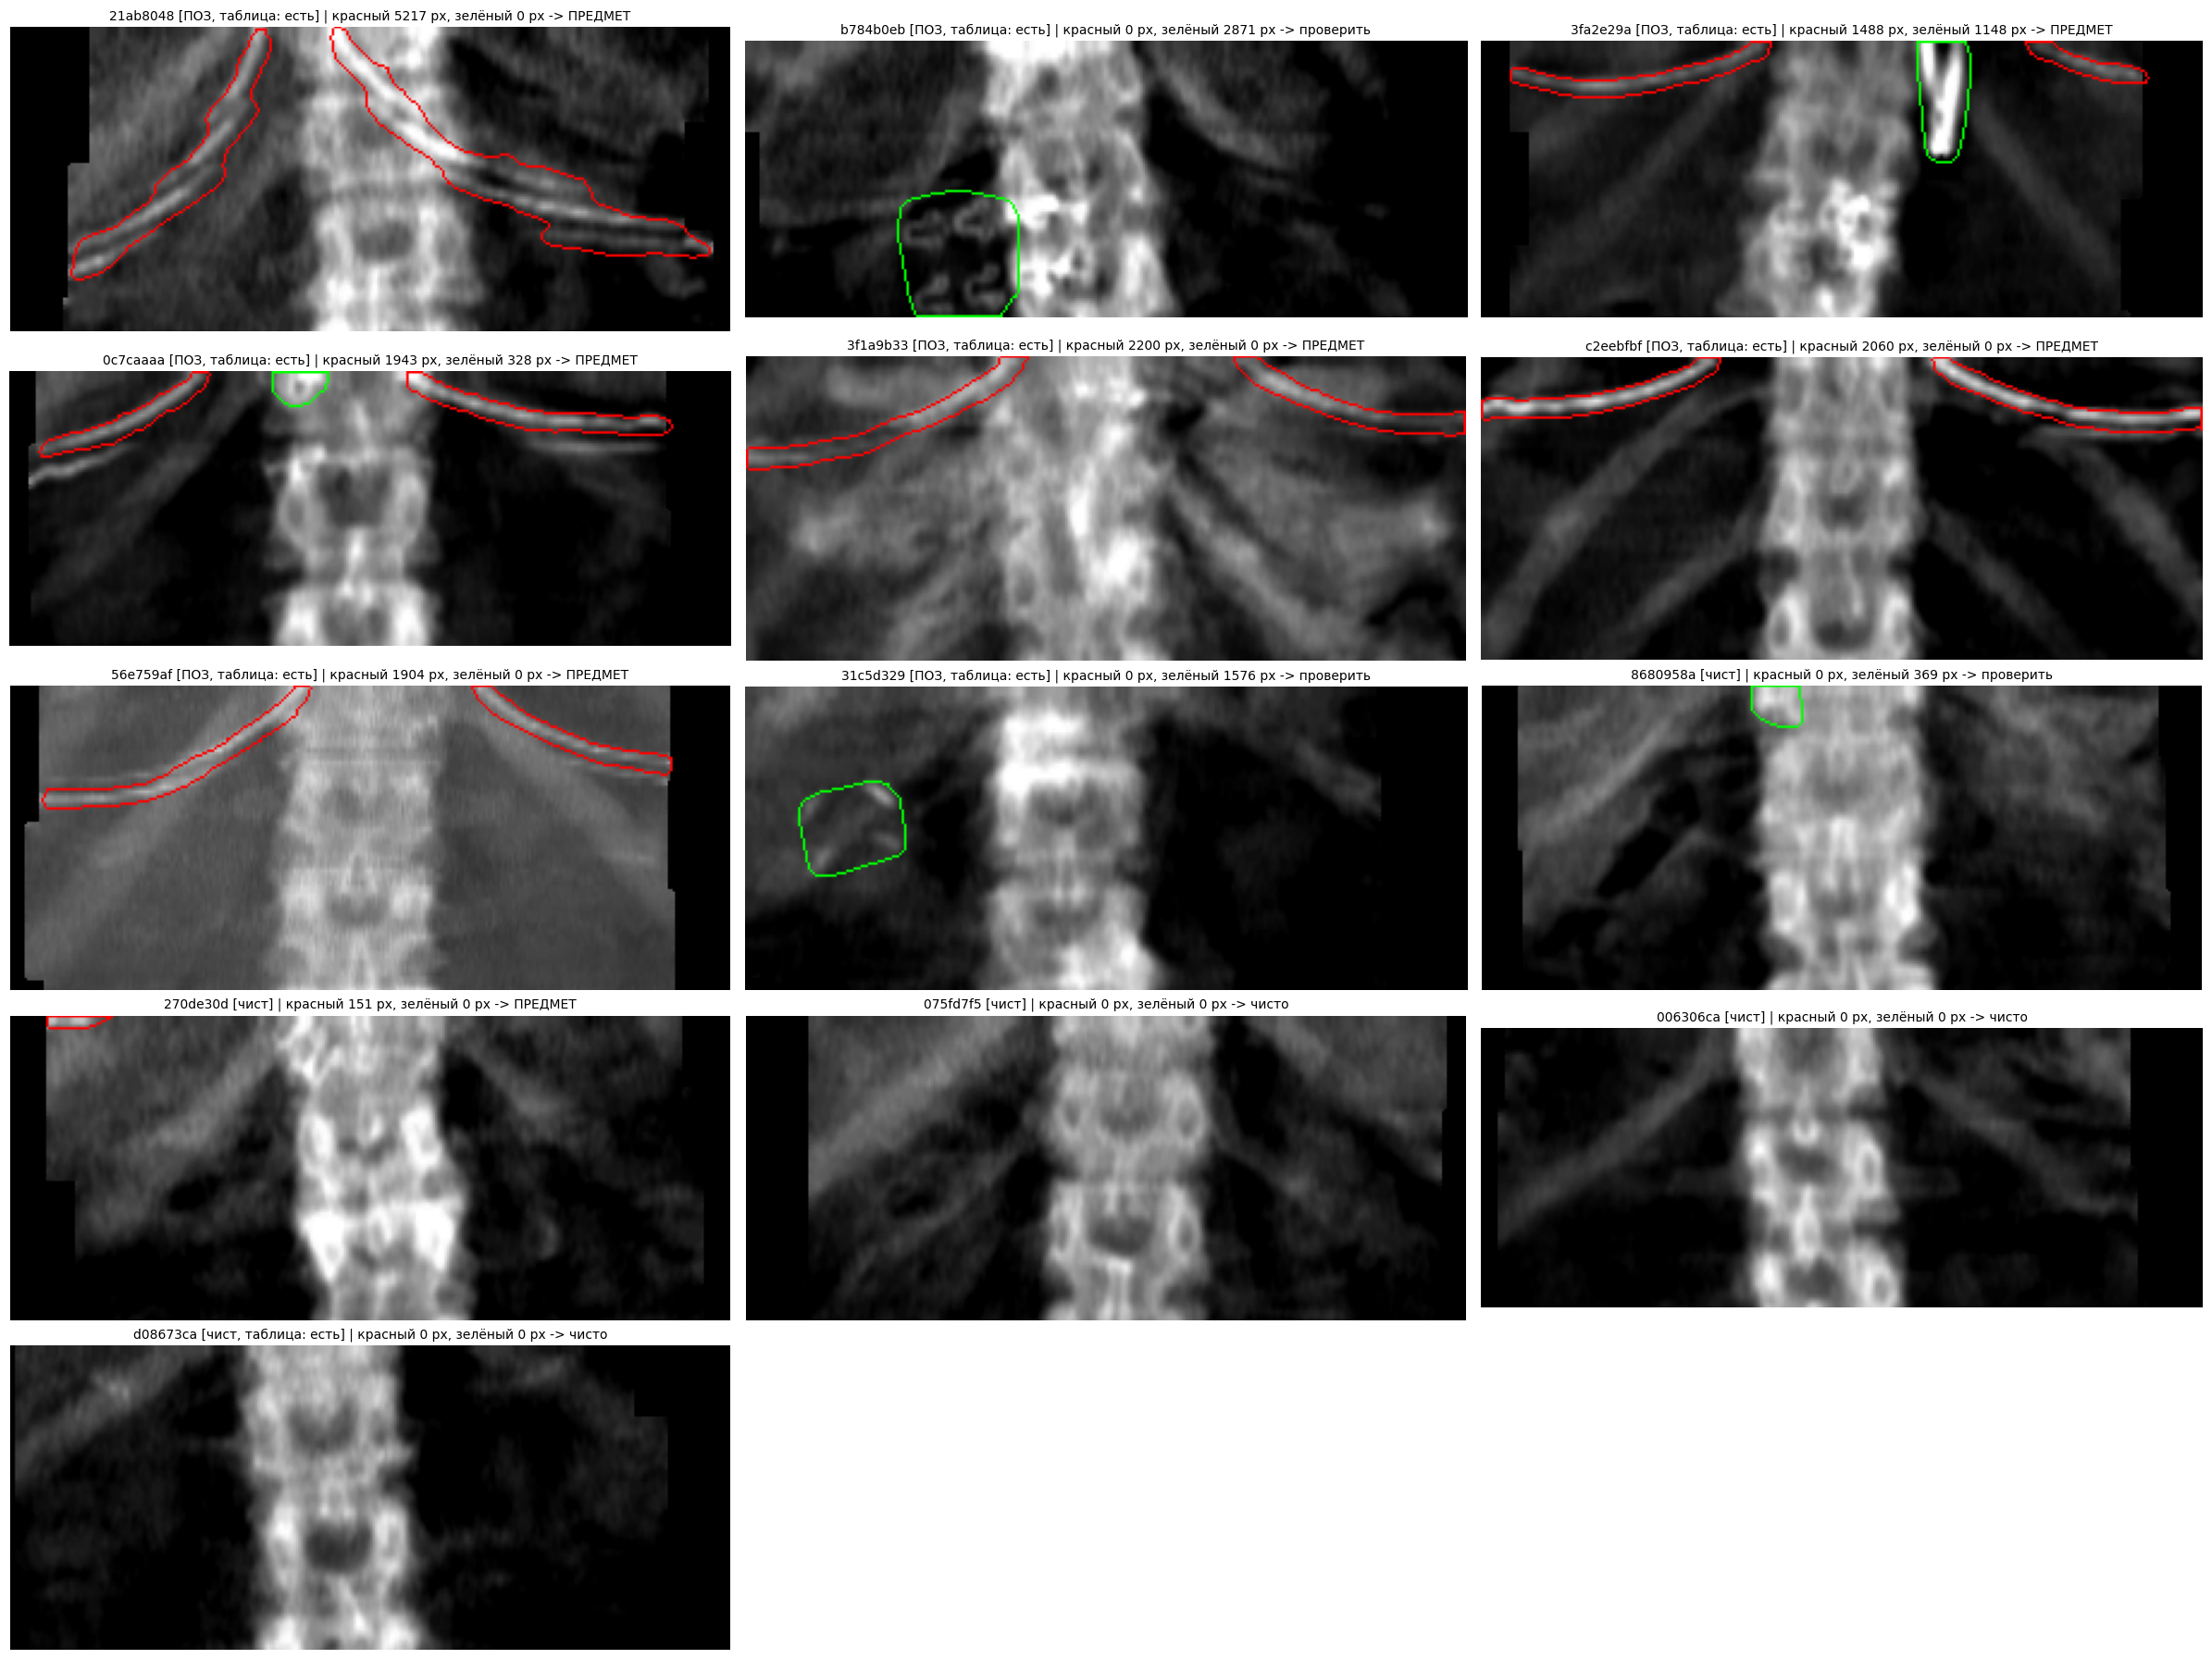

In [62]:
EXTERNAL_DIR = None   # например "/kaggle/input/.../Для_теста"; None — только снимки из выборки

@torch.no_grad()
def predict_image(model, img_u8):
    top = img_u8[:int(round(img_u8.shape[0] * TOP_FRAC))]
    x = (cv2.resize(top, (IMG_W, IMG_H)).astype(np.float32) / 255.0 - 0.449) / 0.226
    xb = torch.from_numpy(x)[None, None].repeat(1, 3, 1, 1).to(device)
    model.eval()
    return top, torch.sigmoid(model(xb))[0].cpu().numpy()

items = []   # (заголовок, полный снимок, имя снимка из выборки или None для внешнего)
if EXTERNAL_DIR:
    for f in sorted(os.listdir(EXTERNAL_DIR)):
        if f.lower().endswith((".png", ".jpg", ".jpeg")):
            g_ = cv2.imread(os.path.join(EXTERNAL_DIR, f), cv2.IMREAD_GRAYSCALE)
            if g_ is not None:
                items.append((f[:14] + " (внешний)", g_, None))
else:
    pos_ = df[df.has_obj == 1].sort_values("score", ascending=False).image_filename.tolist()[:8]
    doubt_ = df[df.has_obj == 0].sort_values("score", ascending=False).image_filename.tolist()[:4]
    flag_ = [n for n in names if labels[n].get("in_table") and not MASKS[n].any()]
    tag_ = lambda n: ("ПОЗ" if n in pos_ else "чист") + (", таблица: есть" if labels[n].get("in_table") else "")
    items = [(f"{n[:8]} [{tag_(n)}]", FULL[n], n) for n in dict.fromkeys(pos_ + doubt_ + flag_)]

cols = 3; rws = math.ceil(len(items) / cols)
fig, ax = plt.subplots(rws, cols, figsize=(8 * cols, 3.6 * rws)); ax = np.atleast_2d(ax)
for a_ in ax.ravel(): a_.axis("off")
for i, (title, full, key) in enumerate(items):
    top, pr = predict_image(final_model, full)
    pmm = pred_masks(pr, top)
    score = int(pmm.any(0).sum())   # в пикселях 320x128, как порог
    pm = resize_mask(pmm, top.shape)
    a_ = ax[i // cols, i % cols]; a_.imshow(overlay(top, pm))
    verdict_ = verdict_levels(pmm)
    a_.set_title(f"{title} | красный {int(pmm[0].sum())} px, зелёный {int(pmm[1].sum())} px -> {verdict_}", fontsize=10)
plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR, "demo_final_model.png"), dpi=70); plt.show()

In [63]:
g = df[df.green_px > 0].copy()
g["снимок"] = g.image_filename.str[:8]
g["застёжка размечена"] = [bool(MASKS[n][1].any()) for n in g.image_filename]
print(g.sort_values("green_px")[["снимок", "застёжка размечена", "green_px", "red_px", "verdict"]].to_string(index=False))

  снимок  застёжка размечена  green_px  red_px   verdict
2081b4a4               False       128    1248   ПРЕДМЕТ
d3660519                True       206     954   ПРЕДМЕТ
0c7caaaa                True       328    1943   ПРЕДМЕТ
8680958a               False       369       0 проверить
26625c20                True       423       0 проверить
87c4f1f8                True       426       0 проверить
9c605d95                True       548       0 проверить
3fa2e29a                True      1148    1488   ПРЕДМЕТ
31c5d329                True      1576       0 проверить
b784b0eb                True      2871       0 проверить


In [64]:
MIN_WIRE_VERDICT_PX = 400   # красных пикселей для вердикта «ПРЕДМЕТ» (у настоящих дужек не меньше 954, ложный кусок в углу был 151)

masks_ = {n: pred_masks(probs[n], IMAGES[n]) for n in df.image_filename}     # probs уже посчитаны ячейкой оценки выше
df["red_px"] = [int(masks_[n][0].sum()) for n in df.image_filename]
df["green_px"] = [int(masks_[n][1].sum()) for n in df.image_filename]
df["verdict"] = [verdict_levels(masks_[n]) for n in df.image_filename]

own = df.has_obj == 1
tab = pd.crosstab(df.has_obj.map({1: "позитив", 0: "чистый"}), df.verdict).reindex(columns=["ПРЕДМЕТ", "проверить", "чисто"], fill_value=0)
print(tab)
print(f"позитивы: ПРЕДМЕТ {(own & (df.verdict == 'ПРЕДМЕТ')).sum()}, проверить {(own & (df.verdict == 'проверить')).sum()}, пропущено {(own & (df.verdict == 'чисто')).sum()} из {own.sum()}")
print(f"чистые: ложное ПРЕДМЕТ {(~own & (df.verdict == 'ПРЕДМЕТ')).sum()}, ложное «проверить» {(~own & (df.verdict == 'проверить')).sum()} из {(~own).sum()}")
print("пропущенные позитивы:", df[own & (df.verdict == 'чисто')].image_filename.str[:8].tolist())
print("ложное ПРЕДМЕТ на чистых:", df[~own & (df.verdict == 'ПРЕДМЕТ')].image_filename.str[:8].tolist())
print("ложное «проверить» на чистых:", df[~own & (df.verdict == 'проверить')].image_filename.str[:8].tolist())
print("красные площади у позитивов, минимум:", int(df[own & (df.red_px > 0)].red_px.min()))
df.to_csv(os.path.join(OUTPUT_DIR, "foreign_train_check.csv"), index=False)

verdict  ПРЕДМЕТ  проверить  чисто
has_obj                           
позитив       14          5      0
чистый         0          1     79
позитивы: ПРЕДМЕТ 14, проверить 5, пропущено 0 из 19
чистые: ложное ПРЕДМЕТ 0, ложное «проверить» 1 из 80
пропущенные позитивы: []
ложное ПРЕДМЕТ на чистых: []
ложное «проверить» на чистых: ['8680958a']
красные площади у позитивов, минимум: 486


In [65]:
import json
gate = {
    "backbone": BACKBONE, "img_size": [IMG_W, IMG_H], "top_frac": TOP_FRAC, "mask_thresh": MASK_THRESH, "bg_median_px": BG_MEDIAN_PX,
    "obj_merge_px": OBJ_MERGE_PX, "max_objects": MAX_OBJECTS, "min_obj_comp_px": MIN_OBJ_COMP_PX, "obj_min_mx": OBJ_MIN_MX,
    "min_wire_len_px": MIN_WIRE_LEN_PX, "min_wire_aspect": MIN_WIRE_ASPECT, "max_wire_top_frac": MAX_WIRE_TOP_FRAC,
    "min_wire_verdict_px": MIN_WIRE_VERDICT_PX, "min_area_px": int(MIN_AREA_PX),
    "verdict_levels": ["ПРЕДМЕТ", "проверить", "чисто"],
}
with open(os.path.join(OUTPUT_DIR, "foreign_seg_gate.json"), "w", encoding="utf-8") as f:
    json.dump(gate, f, ensure_ascii=False, indent=1)
print(json.dumps(gate, ensure_ascii=False, indent=1))

{
 "backbone": "resnet18.tv_in1k",
 "img_size": [
  320,
  128
 ],
 "top_frac": 0.4,
 "mask_thresh": 0.5,
 "bg_median_px": 25,
 "obj_merge_px": 9,
 "max_objects": 1,
 "min_obj_comp_px": 60,
 "obj_min_mx": 77,
 "min_wire_len_px": 30,
 "min_wire_aspect": 2.5,
 "max_wire_top_frac": 0.15,
 "min_wire_verdict_px": 400,
 "min_area_px": 30,
 "verdict_levels": [
  "ПРЕДМЕТ",
  "проверить",
  "чисто"
 ]
}
